<a href="https://colab.research.google.com/github/ThaisEDomingues/Importando_base_kaggle/blob/main/Importando_base_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# se você esta usando bases de dados, do kaggle, para fazer um portifólio, devo:
import kagglehub
import pandas as pd
import os

# caminho da informação - pega o link do usuario
base_dados = input('informe o local da base')
caminho_pasta = kagglehub.dataset_download(base_dados)

#lista todos as pastas do diretório
arquivos = os.listdir(caminho_pasta)

# lê e organiza todos os dados
arquivo_csv = [f for f in arquivos if f.endswith('.csv')][0]
caminho_completo = os.path.join(caminho_pasta, arquivo_csv)
df = pd.read_csv(caminho_completo)

nome_arquivo = input('informe o nome que você quer salvar o arquivo')

df.to_csv(nome_arquivo, index=False)

informe o local da baseashishkumarak/netflix-reviews-playstore-daily-updated
Using Colab cache for faster access to the 'netflix-reviews-playstore-daily-updated' dataset.
informe o nome que você quer salvar o arquivonetflix


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#configurar os visuais de maneira padrão
sns.set_theme(style='whitegrid')


In [12]:
#carregar dados
df_netflix = pd.read_csv('/content/netflix')
df_netflix.info() #para eu analisar a base dados

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151525 entries, 0 to 151524
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              151525 non-null  object
 1   userName              151523 non-null  object
 2   content               151519 non-null  object
 3   score                 151525 non-null  int64 
 4   thumbsUpCount         151525 non-null  int64 
 5   reviewCreatedVersion  124096 non-null  object
 6   at                    151525 non-null  object
 7   appVersion            124096 non-null  object
dtypes: int64(2), object(6)
memory usage: 9.2+ MB


In [13]:
#para ver os primeiros 10 itens da base dados
df_netflix.head(10)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,4afc7d4f-5ccd-4f15-8096-aed195dec9af,Josue Joseph,let Michael Jackson rest in peace 🙏🏽,1,0,NaN,2026-05-27 09:15:17,NaN
1,488fbd96-f4d9-4f92-a330-f92c74f046a0,Oyan Mojumdar,ok,5,0,9.66.0 build 13 64116,2026-05-27 09:11:16,9.66.0 build 13 64116
2,454bbc93-74c3-41df-9693-6b0fc2fa0798,KIRTISIVA,Great performance and high-quality streaming m...,5,0,9.62.0 build 8 64020,2026-05-27 08:56:45,9.62.0 build 8 64020
3,4b6ee540-11f4-498d-9fa9-fec3c5b03b07,Oscar Staana,Netflix is easy to use and has many great movi...,5,0,9.67.1 build 11 64144,2026-05-27 08:54:18,9.67.1 build 11 64144
4,638b512e-9557-4460-aeae-05c1ee2c3e41,Lisakhanya Nobatana,safe and sound,5,0,8.143.5 build 19 52400,2026-05-27 08:34:26,8.143.5 build 19 52400
5,de052e7b-0689-4057-817d-c33d48b9579c,Varin Jain,There are millions of movies and they are good.,5,0,NaN,2026-05-27 08:15:54,NaN
6,987afaaf-c9ad-463a-9389-3b8b917d57e5,Johaira Macalaba,Elio pixar because my daughter did not get the...,5,0,9.67.1 build 11 64144,2026-05-27 08:00:40,9.67.1 build 11 64144
7,9eaf2997-6e6a-460e-b908-0b462e60cd8f,Mustafa Saqib,Lot good app,5,0,9.67.1 build 11 64144,2026-05-27 07:56:16,9.67.1 build 11 64144
8,614bb344-8c83-43f9-8f8a-08c025e2858e,John michael Malate,I unsubscribe and delete this app!! but this a...,1,0,NaN,2026-05-27 07:51:42,NaN
9,347d4381-b96c-483c-9000-348d5218c285,علی نیٹ پرنٹ شاپ,payment problem many times error,1,0,9.62.0 build 8 64020,2026-05-27 07:50:55,9.62.0 build 8 64020


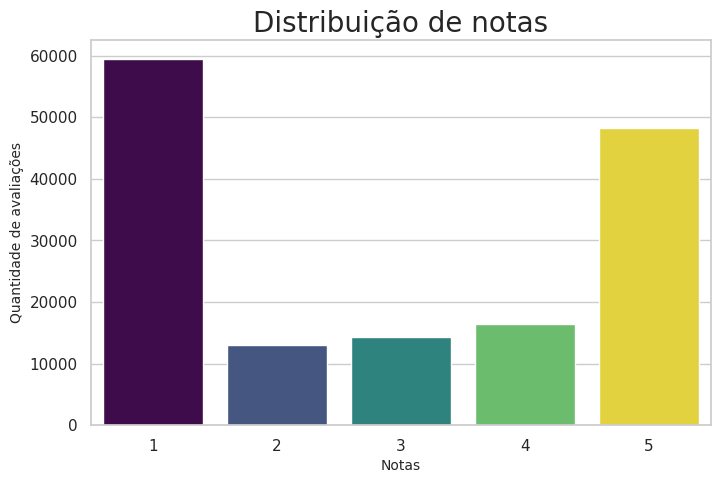

In [18]:
#criar um grafico para mostrar a distribuição de notas
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df_netflix, x = 'score', hue='score', palette='viridis', legend=False)

plt.title('Score distribuition')


plt.title('Distribuição de notas', fontsize=20)
plt.xlabel('Notas', fontsize=10)
plt.ylabel('Quantidade de avaliações', fontsize=10)
plt.show()



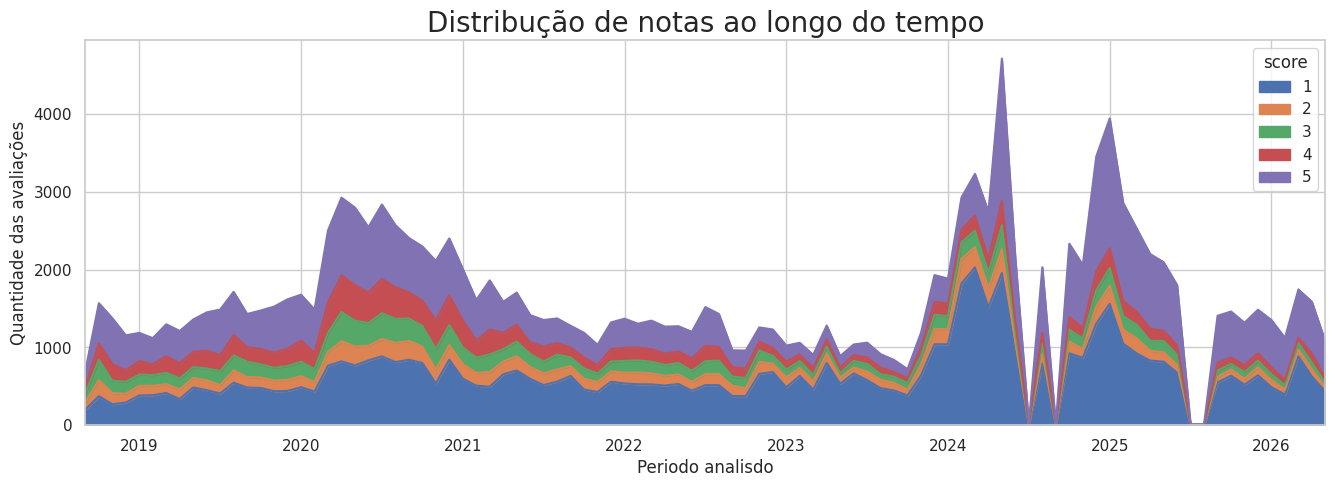

In [26]:
# força um campo a virar uma data
df_netflix['at'] = pd.to_datetime(df_netflix['at'])
# coleta apenas a informação ANO e MES do campo data
df_netflix['ano_mes'] = df_netflix['at'].dt.to_period('M')

# a evolução das notas no decorrer do periodo analisado
score_mensal = df_netflix.groupby(['ano_mes','score']).size().unstack(fill_value=0)

score_mensal.plot(kind='area', figsize=(16,5))
plt.title('Distribução de notas ao longo do tempo', fontsize=20)
plt.ylabel('Quantidade das avaliações')
plt.xlabel('Periodo analisdo')
plt.show()